# Etapa 2 CRISP-DM — Comprensión y Preparación de los Datos
## MA2007B · Uso de geometría y topología para ciencia de datos

**Proyecto:** TDA en la Salud Materno-Infantil: Impacto del Ácido Fólico en Mujeres Chilenas  
**Base de datos:** `1. Ingesta de AF en embarazo FINAL.xlsx` — Hoja: *BD Artículo*  
**Equipo:** Valeria Arciga · Ximena Montes · Brisma Alvarez · Paulina Castellanos · Emiliano Ruiz  
**ITESM · 2026**


## Importación de librerías

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
sns.set_style('whitegrid')
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'figure.dpi': 120
})

PALETTE = {
    'primary':   '#2E5FA3',
    'secondary': '#E84855',
    'accent':    '#F4B942',
    'green':     '#3BB273',
    'light':     '#A8C5E8',
    'gray':      '#6C757D'
}


<a id='1'></a>
## Carga e inspección inicial

In [14]:
from pathlib import Path

FILE_PATH = Path('..') / 'Data' / 'Ingesta_AF_embarazo.xlsx'

df = pd.read_excel(FILE_PATH, sheet_name='BD Artículo')

print(f'   Registros : {df.shape[0]:,}')
print(f'   Columnas  : {df.shape[1]}')
print()
print('Primeras 3 filas:')
df.head(10)

   Registros : 1,170
   Columnas  : 63

Primeras 3 filas:


,Cod,edad,region_chile,neduc,paridad,fnacimiento,Sexo,pnacer,Edad_gestacion ultimo hijo,sitgest,...,otro,"Durante su embarazo, ¿qué tipo de pan consumió?",Marraqueta,Hallulla,Pan molde blanco,Pan molde integral,pan pita,no como pan,otro.1,N° PANES
0,1,26.0,1,4,1,2015-01-15 00:00:00,2,3040,39,9,...,0,Hallulla,0,1,0,0,0,0,0,2
1,2,36.0,1,6,2,2012-03-29 00:00:00,2,3875,39,5,...,0,Marraqueta - Pan Batido - Pan Francés,1,0,0,0,0,0,0,3
2,3,22.0,1,5,1,2011-11-22 00:00:00,1,2665,38,0,...,0,Marraqueta - Pan Batido - Pan Francés,1,0,0,0,0,0,0,2
3,4,35.0,1,3,2,2007-02-14 00:00:00,1,3450,37,0,...,0,Marraqueta - Pan Batido - Pan Francés,1,0,0,0,0,0,0,2
4,5,33.0,1,5,0,NaN,0,NaN,NaN,0,...,0,Marraqueta - Pan Batido - Pan Francés,1,0,0,0,0,0,0,3
5,6,31.0,1,6,1,2014-08-25 00:00:00,1,3430,38,0,...,0,Hallulla,0,1,0,0,0,0,0,0.5
6,7,34.0,1,7,1,2016-03-22 00:00:00,1,3710,39,10,...,0,Marraqueta - Pan Batido - Pan Francés,1,0,0,0,0,0,0,No a diario
7,8,26.0,1,4,1,2015-12-19 00:00:00,1,3350,38,0,...,0,Marraqueta - Pan Batido - Pan Francés,1,0,0,0,0,0,0,2
8,9,24.0,1,5,1,2011-07-25 00:00:00,1,3120,40,9,...,0,Marraqueta - Pan Batido - Pan Francés,1,0,0,0,0,0,0,2
9,10,26.0,1,6,1,2005-11-04 00:00:00,2,2500,37,9,...,0,Marraqueta - Pan Batido - Pan Francés,1,0,0,0,0,0,0,2


In [15]:
# Ver también el codebook (Hoja2)
codebook = pd.read_excel(FILE_PATH, sheet_name='Hoja2')
print('=== CODEBOOK (Hoja2) ===')
codebook.dropna(subset=[0]).to_string(index=False)

=== CODEBOOK (Hoja2) ===


'                                                                                                        Unnamed: 0    0                                             nada\nUsted tuvo antes o durante el embarazo alguna de estas condiciones o estuvo expuesta a alguna de estas situaciones  1.0                                         alergias\n                                                                                                         (sitgest)  2.0                                           anemia\n                                                                                                               NaN  3.0                                        prematuro\n                                                                                                               NaN  4.0              exposición a drogas antes o durante\n                                                                                                               NaN  5.0                             d

In [16]:
# Tipos de datos y valores no nulos
print('=== Tipos de datos ===')
df.info()

=== Tipos de datos ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 63 columns):
 #   Column                                                                   Non-Null Count  Dtype  
---  ------                                                                   --------------  -----  
 0   Cod                                                                      1170 non-null   int64  
 1   edad                                                                     1169 non-null   float64
 2   region_chile                                                             1170 non-null   int64  
 3   neduc                                                                    1170 non-null   int64  
 4   paridad                                                                  1170 non-null   object 
 5   fnacimiento                                                              1038 non-null   object 
 6   Sexo                                             

<a id='2'></a>
## Dimensión del dataset

In [17]:
n_rows, n_cols = df.shape
n_nulls_total  = df.isnull().sum().sum()
n_cells        = n_rows * n_cols
pct_missing    = n_nulls_total / n_cells * 100
n_duplicates   = df.duplicated().sum()

resumen = pd.DataFrame({
    'Métrica': ['Registros (filas)', 'Variables (columnas)', 'Celdas totales',
                'Valores nulos totales', '% datos faltantes (global)', 'Registros duplicados'],
    'Valor': [f'{n_rows:,}', f'{n_cols}', f'{n_cells:,}',
              f'{n_nulls_total:,}', f'{pct_missing:.2f}%', f'{n_duplicates}']
})
print('Dimensión del Dataset')
resumen

Dimensión del Dataset


,Métrica,Valor
0,Registros (filas),"1,170"
1,Variables (columnas),63
2,Celdas totales,"73,710"
3,Valores nulos totales,876
4,% datos faltantes (global),1.19%
5,Registros duplicados,0


<a id='3'></a>
## Descripción de variables

### Mapa de codebooks

In [18]:
# Codebooks para variables categóricas codificadas
REGION_MAP = {
    1:'I. Tarapacá', 2:'II. Antofagasta', 3:'III. Atacama', 4:'IV. Coquimbo',
    5:'V. Valparaíso', 6:"VI. O'Higgins", 7:'VII. Maule', 8:'VIII. Biobío',
    9:'IX. Araucanía', 10:'X. Los Lagos', 11:'XI. Aysén', 12:'XII. Magallanes',
    13:'XIII. Metropolitana', 14:'XIV. Los Ríos', 15:'XV. Arica y Parinacota', 16:'XVI. Ñuble'
}

NEDUC_MAP = {
    1:'Sin estudios', 2:'Básica incompleta', 3:'Básica completa',
    4:'Media incompleta', 5:'Media completa',
    6:'Superior incompleta', 7:'Superior completa'
}

SITGEST_MAP = {
    0:'Ninguna', 1:'Alergias', 2:'Anemia', 3:'Prematuro previo',
    4:'Exp. drogas', 5:'Diabetes gestacional', 6:'Colestasia',
    7:'Desp. placenta', 8:'Depresión', 9:'Exp. cigarro',
    10:'Prob. tiroídeos', 11:'Embarazo múltiple', 12:'Exp. pesticidas',
    13:'Preeclampsia', 14:'RCIU', 15:'Hiperemesis gravídica',
    16:'Infección (neumonía)', 17:'Resistencia a insulina', 18:'Taquicardia fetal'
}

PROBNAC_MAP = {
    0:'Ninguno', 1:'Alergia alimentaria', 2:'Cardiopatía congénita + taquicardia',
    3:'Enf. pulmonar (EMH/DBP)', 4:'PEG severo', 5:'Otro (sin rel. crec.)',
    6:'Pielectasia renal', 7:'DTN', 8:'Ictericia',
    9:'Alt. neurológicas', 10:'Convulsión', 11:'Hipotiroidismo'
}

SEXO_MAP = {0: 'No registrado', 1: 'Masculino', 2: 'Femenino'}

print('Codebooks definidos')
pd.DataFrame.from_dict(NEDUC_MAP, orient='index', columns=['Nivel Educacional'])

Codebooks definidos


,Nivel Educacional
1,Sin estudios
2,Básica incompleta
3,Básica completa
4,Media incompleta
5,Media completa
6,Superior incompleta
7,Superior completa


In [19]:
# Catálogo  de variables
catalogo = pd.DataFrame([
    # Identificación
    ['Cod',              'ID único del registro',                            'Numérico discreto',   '1 — 1170',                      0],
    ['edad',             'Edad de la madre (años)',                          'Numérico continuo',   '15 — 55 (tras limpieza)',       df['edad'].isna().sum()],
    ['region_chile',     'Región de residencia (codificada)',                'Categórico nominal',   '1 — 16 (15 regiones)',          0],
    ['neduc',            'Nivel educacional materno',                        'Categórico ordinal',   '1=Sin estudios … 7=Sup.comp.',  0],
    ['paridad',          'N° de hijos previos',                              'Categórico ordinal',   '0, 1, 2, 3, 4, 5+',            0],
    ['fnacimiento',      'Fecha de nacimiento del último hijo',              'Fecha',               '1985 — 2017',                   df['fnacimiento'].isna().sum()],
    ['Sexo',             'Sexo del recién nacido',                           'Categórico nominal',   '1=Masc., 2=Fem., 0=No reg.',   0],
    # Resultados neonatales
    ['pnacer',           'Peso al nacer (g)',                                'Numérico continuo',   '800 — 5450 g (tras limpieza)', df['pnacer'].isna().sum()],
    ['Edad_gestacion ultimo hijo', 'Edad gestacional al parto (semanas)',   'Numérico continuo',   '32 — 42 sem. (tras limpieza)', df['Edad_gestacion ultimo hijo'].isna().sum()],
    ['probnac',          'Problema de salud al nacer',                       'Categórico nominal',   '0=Ninguno, 1–11=tipo',         df['probnac'].isna().sum()],
    # Condición materna
    ['sitgest',          'Condición médica durante gestación',               'Categórico nominal',   '0=Ninguna, 1–18=condición',    0],
    ['Preeclamsia',      'Presencia de preeclampsia',                        'Binario',             '0=No, 1=Sí',                   0],
    ['Diabetes gestacional', 'Diagnóstico de diabetes gestacional',         'Binario',             '0=No, 1=Sí',                   df['Diabetes gestacional'].isna().sum()],
    ['Embarazo multiple','Embarazo múltiple (gemelos, etc.)',                'Binario',             '0=No, 1=Sí',                   df['Embarazo multiple'].isna().sum()],
    ['Exposición directa o indirecta al humo del cigarro', 'Exp. cigarro',  'Binario',             '0=No, 1=Sí',                   0],
    ['Consumo de drogas antes o durante el embarazo', 'Exp. drogas',        'Binario',             '0=No, 1=Sí',                   0],
    ['Restricción del crecimiento intrauterino RCIU', 'RCIU',               'Binario',             '0=No, 1=Sí',                   df['Restricción del crecimiento intrauterino RCIU'].isna().sum()],
    # Suplementación
    ['uf-af',            'Dosis diaria de suplemento AF (µg/día)',           'Numérico discreto',   '200, 600, 800, 900, 1000, 2000, 2500, 2900, 5000', df['uf-af'].isna().sum()],
    ['NO consumio',      'No consumió ningún suplemento AF',                 'Binario',             '0=Sí consumió, 1=No consumió', 0],
    ['Antes del embarazo','Tomó suplemento antes del embarazo',              'Binario',             '0=No, 1=Sí',                   0],
    ['Durante todo el embarazo', 'Tomó suplemento todo el embarazo',         'Binario',             '0=No, 1=Sí',                   0],
    ['No consumi suplemento en ningun periodo', 'No usó suplemento',         'Binario',             '0=No, 1=Sí',                   0],
    # Pan
    ['Marraqueta',       'Consumió pan marraqueta durante embarazo',         'Binario',             '0=No, 1=Sí',                   0],
    ['Hallulla',         'Consumió hallulla',                                'Binario',             '0=No, 1=Sí',                   0],
    ['Pan molde blanco', 'Consumió pan molde blanco',                        'Binario',             '0=No, 1=Sí',                   0],
    ['Pan molde integral','Consumió pan molde integral',                     'Binario',             '0=No, 1=Sí',                   0],
    ['N° PANES',         'N° de panes consumidos al día',                   'Numérico discreto',   '0 — 8+ (algunos no diarios)',  df['N° PANES'].isna().sum()],
], columns=['Variable', 'Descripción', 'Tipo', 'Valores posibles', 'Nulos'])

print(f'Catálogo de variables principales ({len(catalogo)} variables mostradas de {df.shape[1]} totales)')
catalogo.style.set_properties(**{'text-align': 'left'}).hide(axis='index')

Catálogo de variables principales (27 variables mostradas de 63 totales)


Variable,Descripción,Tipo,Valores posibles,Nulos
Cod,ID único del registro,Numérico discreto,1 — 1170,0
edad,Edad de la madre (años),Numérico continuo,15 — 55 (tras limpieza),1
region_chile,Región de residencia (codificada),Categórico nominal,1 — 16 (15 regiones),0
neduc,Nivel educacional materno,Categórico ordinal,1=Sin estudios … 7=Sup.comp.,0
paridad,N° de hijos previos,Categórico ordinal,"0, 1, 2, 3, 4, 5+",0
fnacimiento,Fecha de nacimiento del último hijo,Fecha,1985 — 2017,132
Sexo,Sexo del recién nacido,Categórico nominal,"1=Masc., 2=Fem., 0=No reg.",0
pnacer,Peso al nacer (g),Numérico continuo,800 — 5450 g (tras limpieza),111
Edad_gestacion ultimo hijo,Edad gestacional al parto (semanas),Numérico continuo,32 — 42 sem. (tras limpieza),103
probnac,Problema de salud al nacer,Categórico nominal,"0=Ninguno, 1–11=tipo",1


<a id='4'></a>
## Estadísticas descriptivas — Variables cuantitativas

In [20]:
# Convertir variables numéricas que están como object
df['pnacer_raw'] = pd.to_numeric(df['pnacer'], errors='coerce')
df['eg_raw']     = pd.to_numeric(df['Edad_gestacion ultimo hijo'], errors='coerce')
df['uf_af']      = pd.to_numeric(df['uf-af'], errors='coerce')
df['n_panes']    = pd.to_numeric(df['N° PANES'], errors='coerce')

quant_vars = {
    'Edad materna (años)':          'edad',
    'Peso al nacer (g)':            'pnacer_raw',
    'Edad gestacional (semanas)':   'eg_raw',
    'Dosis suplemento AF (µg/día)': 'uf_af',
    'N° panes / día':               'n_panes',
}

rows = []
for label, col in quant_vars.items():
    d = df[col].dropna()
    rows.append({
        'Variable': label,
        'n válidos': len(d),
        'Nulos': df[col].isna().sum(),
        'Media': round(d.mean(), 2),
        'Mediana': round(d.median(), 2),
        'Moda': round(d.mode().iloc[0], 2),
        'Mín': round(d.min(), 2),
        'Máx': round(d.max(), 2),
        'Rango': round(d.max() - d.min(), 2),
        'Desv. Std': round(d.std(), 2),
        'Varianza': round(d.var(), 2),
        'Q1': round(d.quantile(0.25), 2),
        'Q3': round(d.quantile(0.75), 2),
        'IQR': round(d.quantile(0.75) - d.quantile(0.25), 2),
        'Asimetría': round(stats.skew(d), 3),
        'Curtosis': round(stats.kurtosis(d), 3),
    })

stats_df = pd.DataFrame(rows).set_index('Variable')
print('Medidas de tendencia central ')
stats_df

Medidas de tendencia central 


,n válidos,Nulos,Media,Mediana,Moda,Mín,Máx,Rango,Desv. Std,Varianza,Q1,Q3,IQR,Asimetría,Curtosis
Variable,,,,,,,,,,,,,,,
Edad materna (años),1169,1,30.08,29.0,26.0,15.0,227.0,212.0,8.59,73.85,26.0,34.0,8.0,10.597,235.429
Peso al nacer (g),1056,114,3348.13,3390.0,3450.0,179.0,5450.0,5271.0,543.27,295138.65,3050.0,3662.5,612.5,-0.766,3.554
Edad gestacional (semanas),1052,118,38.52,39.0,38.0,0.0,42.0,42.0,2.25,5.05,38.0,40.0,2.0,-9.699,162.355
Dosis suplemento AF (µg/día),647,523,2728.75,1000.0,1000.0,200.0,5000.0,4800.0,1915.97,3670936.98,1000.0,5000.0,4000.0,0.278,-1.836
N° panes / día,1136,34,2.05,2.0,2.0,0.0,8.0,8.0,0.89,0.78,1.0,2.0,1.0,0.628,1.628


<a id='5'></a>
## Tablas de distribución de frecuencias — Variables cualitativas

In [21]:
def tabla_frecuencias(serie, nombre_variable, mapa=None):
    """Genera tabla de distribución de frecuencias para una variable categórica."""
    conteos = serie.value_counts(dropna=False)
    freq_df = pd.DataFrame({
        'Código': conteos.index,
        'Frecuencia abs.': conteos.values,
        'Frecuencia rel. (%)': (conteos.values / conteos.sum() * 100).round(2),
        'Frec. acumulada (%)': (conteos.values / conteos.sum() * 100).cumsum().round(2)
    })
    if mapa:
        freq_df.insert(1, 'Descripción', freq_df['Código'].map(mapa).fillna('Otro/texto libre'))
    freq_df = freq_df.reset_index(drop=True)
    # Mediana ordinal: solo si los códigos son numéricos ordenados
    codigos_num = pd.to_numeric(serie, errors='coerce').dropna()
    mediana_ord = codigos_num.median() if len(codigos_num) > 0 else 'N/A'
    print(f'\n{nombre_variable}')
    if mapa and mediana_ord != 'N/A':
        med_label = mapa.get(int(mediana_ord), mediana_ord)
        print(f'  Mediana (escala ordinal): {mediana_ord} → {med_label}')
    return freq_df

# Nivel educacional
display(tabla_frecuencias(df['neduc'], 'Nivel Educacional', NEDUC_MAP))


Nivel Educacional
  Mediana (escala ordinal): 5.0 → Media completa


,Código,Descripción,Frecuencia abs.,Frecuencia rel. (%),Frec. acumulada (%)
0,6,Superior incompleta,453,38.72,38.72
1,4,Media incompleta,312,26.67,65.38
2,5,Media completa,234,20.00,85.38
3,7,Superior completa,98,8.38,93.76
4,3,Básica completa,56,4.79,98.55
5,2,Básica incompleta,13,1.11,99.66
6,1,Sin estudios,4,0.34,100.00


In [22]:
display(tabla_frecuencias(df['paridad'], 'Paridad (N° hijos previos)'))


Paridad (N° hijos previos)


,Código,Frecuencia abs.,Frecuencia rel. (%),Frec. acumulada (%)
0,1,635,54.27,54.27
1,2,319,27.26,81.54
2,0,99,8.46,90.00
3,3,92,7.86,97.86
4,4,19,1.62,99.49
5,5 o más,6,0.51,100.00


In [23]:
display(tabla_frecuencias(df['Sexo'], 'Sexo del Recién Nacido', SEXO_MAP))


Sexo del Recién Nacido
  Mediana (escala ordinal): 1.0 → Masculino


,Código,Descripción,Frecuencia abs.,Frecuencia rel. (%),Frec. acumulada (%)
0,1,Masculino,596,50.94,50.94
1,2,Femenino,521,44.53,95.47
2,0,No registrado,53,4.53,100.00


In [24]:
display(tabla_frecuencias(df['sitgest'], 'Condición durante Gestación (sitgest)', SITGEST_MAP))


Condición durante Gestación (sitgest)
  Mediana (escala ordinal): 0.0 → Ninguna


,Código,Descripción,Frecuencia abs.,Frecuencia rel. (%),Frec. acumulada (%)
0,0,Ninguna,737,62.99,62.99
1,9,Exp. cigarro,153,13.08,76.07
2,5,Diabetes gestacional,118,10.09,86.15
3,13,Preeclampsia,49,4.19,90.34
4,4,Exp. drogas,26,2.22,92.56
5,11,Embarazo múltiple,19,1.62,94.19
6,14,RCIU,15,1.28,95.47
7,10,Prob. tiroídeos,13,1.11,96.58
8,6,Colestasia,9,0.77,97.35
9,7,Desp. placenta,4,0.34,97.69


In [25]:
display(tabla_frecuencias(df['probnac'], 'Problema al Nacer (probnac)', PROBNAC_MAP))


Problema al Nacer (probnac)
  Mediana (escala ordinal): 0.0 → Ninguno


,Código,Descripción,Frecuencia abs.,Frecuencia rel. (%),Frec. acumulada (%)
0,0,Ninguno,1093,93.42,93.42
1,5,Otro (sin rel. crec.),25,2.14,95.56
2,2,Cardiopatía congénita + taquicardia,10,0.85,96.41
3,6,Pielectasia renal,9,0.77,97.18
4,8,Ictericia,6,0.51,97.69
5,1,Alergia alimentaria,5,0.43,98.12
6,9,Alt. neurológicas,5,0.43,98.55
7,3,Enf. pulmonar (EMH/DBP),5,0.43,98.97
8,11,Hipotiroidismo,3,0.26,99.23
9,4,PEG severo,2,0.17,99.40


In [26]:
display(tabla_frecuencias(df['region_chile'], 'Región de Chile', REGION_MAP))


Región de Chile
  Mediana (escala ordinal): 9.0 → IX. Araucanía


,Código,Descripción,Frecuencia abs.,Frecuencia rel. (%),Frec. acumulada (%)
0,13,XIII. Metropolitana,437,37.35,37.35
1,5,V. Valparaíso,252,21.54,58.89
2,8,VIII. Biobío,109,9.32,68.21
3,9,IX. Araucanía,63,5.38,73.59
4,14,XIV. Los Ríos,60,5.13,78.72
5,4,IV. Coquimbo,59,5.04,83.76
6,7,VII. Maule,46,3.93,87.69
7,2,II. Antofagasta,33,2.82,90.51
8,15,XV. Arica y Parinacota,33,2.82,93.33
9,6,VI. O'Higgins,28,2.39,95.73


In [27]:
# Distribución de consumo de pan
pan_cols   = ['Marraqueta', 'Hallulla', 'Pan molde blanco', 'Pan molde integral', 'pan pita', 'no como pan', 'otro.1']
pan_sums   = df[pan_cols].sum()
pan_pct    = (pan_sums / len(df) * 100).round(2)
pan_table  = pd.DataFrame({'Tipo de Pan': pan_cols, 'Frecuencia': pan_sums.values, '% del total': pan_pct.values})
pan_table  = pan_table.sort_values('Frecuencia', ascending=False).reset_index(drop=True)
print('Tipo de Pan Consumido durante el Embarazo ')
pan_table

Tipo de Pan Consumido durante el Embarazo 


,Tipo de Pan,Frecuencia,% del total
0,Marraqueta,777,66.41
1,Hallulla,230,19.66
2,Pan molde integral,129,11.03
3,Pan molde blanco,79,6.75
4,pan pita,57,4.87
5,no como pan,16,1.37
6,otro.1,14,1.20


In [28]:
# Período de consumo de suplemento
period_cols   = ['Antes del embarazo','1-3 meses','4-6 meses','7-9 meses',
                 'Durante todo el embarazo','Durante el periodo de lactancia',
                 'No consumi suplemento en ningun periodo']
period_labels = ['Pre-embarazo','1–3 meses','4–6 meses','7–9 meses',
                 'Todo el embarazo','Lactancia','No consumió suplemento']
period_sums   = df[period_cols].sum()
period_pct    = (period_sums / len(df) * 100).round(2)
period_table  = pd.DataFrame({'Período': period_labels,
                               'Frecuencia': period_sums.values,
                               '% del total': period_pct.values})
print('Período de Consumo de Suplemento AF')
period_table

Período de Consumo de Suplemento AF


,Período,Frecuencia,% del total
0,Pre-embarazo,206,17.61
1,1–3 meses,482,41.20
2,4–6 meses,183,15.64
3,7–9 meses,48,4.10
4,Todo el embarazo,343,29.32
5,Lactancia,26,2.22
6,No consumió suplemento,152,12.99


In [29]:
# Dosis de suplemento AF
n_sup = df['uf_af'].notna().sum()
uf_counts = df['uf_af'].value_counts().sort_index()
uf_table  = pd.DataFrame({
    'Dosis (µg/día)': uf_counts.index.astype(int),
    'Frecuencia': uf_counts.values,
    '% (entre las que suplementaron)': (uf_counts.values / n_sup * 100).round(2)
})
print(f'Dosis de Suplemento AF (n = {n_sup} mujeres que suplementaron)')
uf_table.reset_index(drop=True)

Dosis de Suplemento AF (n = 647 mujeres que suplementaron)


,Dosis (µg/día),Frecuencia,% (entre las que suplementaron)
0,200,2,0.31
1,600,10,1.55
2,800,2,0.31
3,900,21,3.25
4,1000,293,45.29
5,2000,23,3.55
6,2500,17,2.63
7,2800,1,0.15
8,2900,17,2.63
9,5000,261,40.34


<a id='6'></a>
## Visualizaciones — Variables cuantitativas

### Histogramas — Análisis de distribución

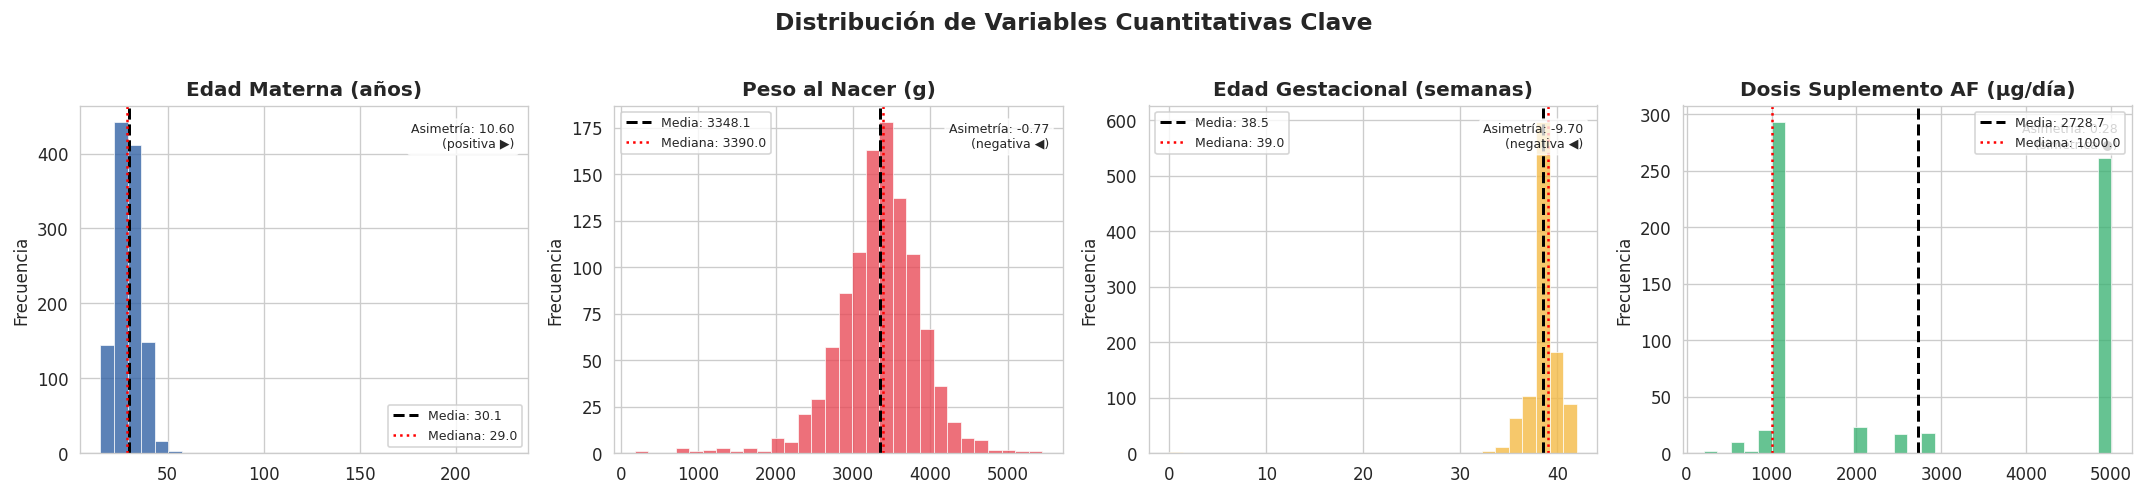

In [30]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Distribución de Variables Cuantitativas Clave', fontsize=14, fontweight='bold', y=1.02)

vars_hist = [
    ('edad',      'Edad Materna (años)',           PALETTE['primary']),
    ('pnacer_raw','Peso al Nacer (g)',              PALETTE['secondary']),
    ('eg_raw',    'Edad Gestacional (semanas)',     PALETTE['accent']),
    ('uf_af',     'Dosis Suplemento AF (µg/día)',   PALETTE['green']),
]

for ax, (col, label, color) in zip(axes, vars_hist):
    data = df[col].dropna()
    ax.hist(data, bins=30, color=color, alpha=0.78, edgecolor='white', linewidth=0.5)
    ax.axvline(data.mean(),   color='black', lw=1.8, ls='--', label=f'Media: {data.mean():.1f}')
    ax.axvline(data.median(), color='red',   lw=1.5, ls=':',  label=f'Mediana: {data.median():.1f}')
    skew_val = stats.skew(data)
    skew_txt = f'Asimetría: {skew_val:.2f}\n' + ('(positiva ▶)' if skew_val > 0.5 else
                                                   '(negativa ◀)' if skew_val < -0.5 else '(simétrica ●)')
    ax.set_title(label)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=7.5)
    ax.text(0.97, 0.95, skew_txt, transform=ax.transAxes, fontsize=7.5,
            ha='right', va='top', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.75))

plt.tight_layout()
plt.show()

### Boxplots — Cuartiles y valores atípicos (outliers)

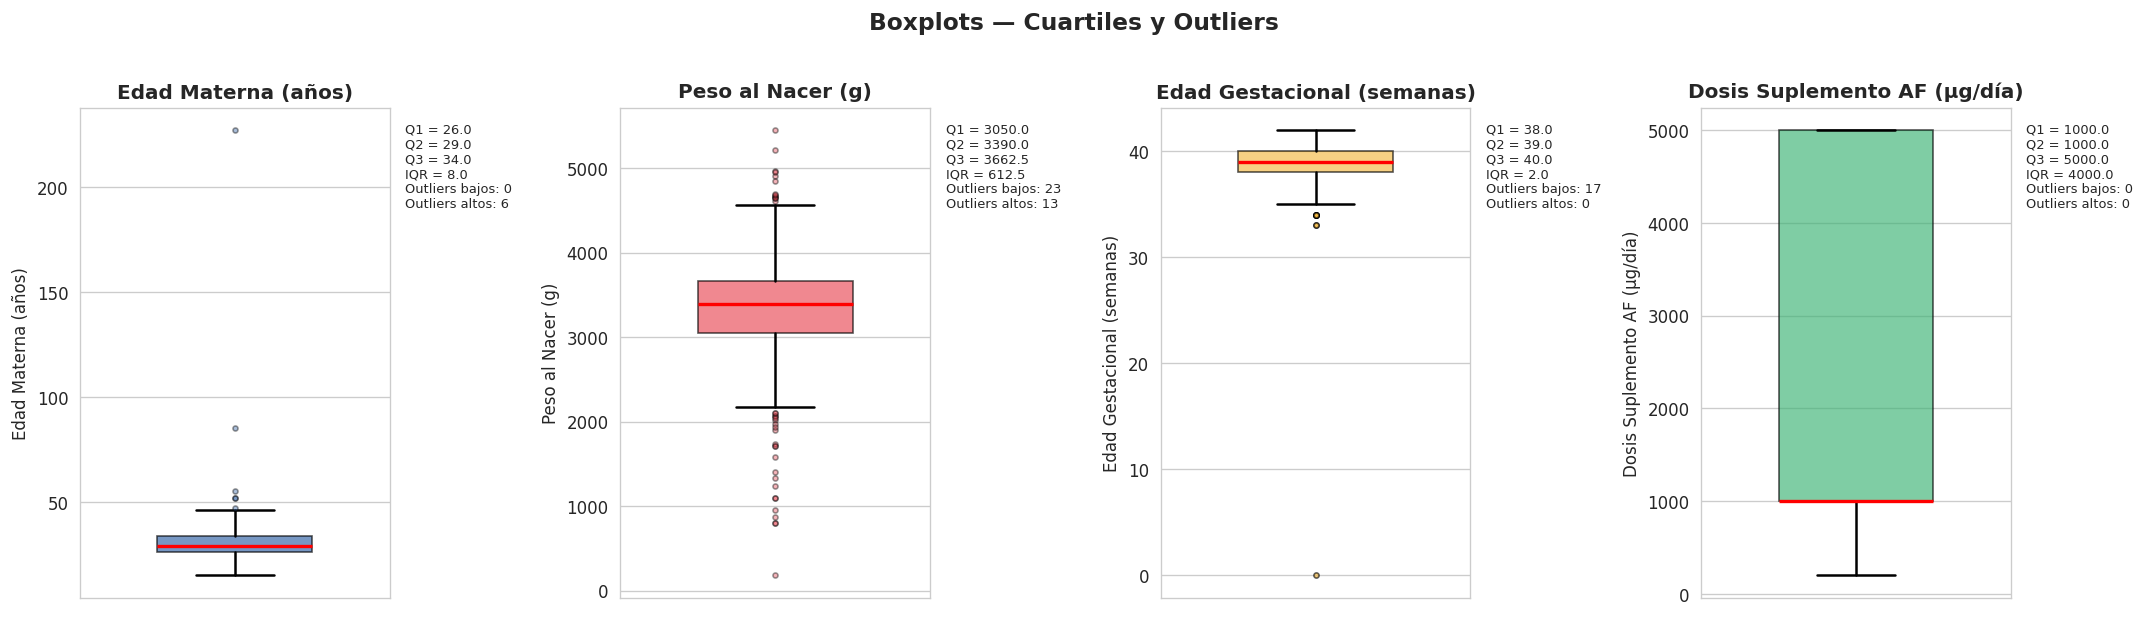

In [31]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Boxplots — Cuartiles y Outliers', fontsize=14, fontweight='bold', y=1.02)

colors_box = [PALETTE['primary'], PALETTE['secondary'], PALETTE['accent'], PALETTE['green']]

for ax, (col, label, color) in zip(axes, vars_hist):
    data = df[col].dropna()
    q1, q2, q3 = data.quantile([0.25, 0.50, 0.75])
    iqr = q3 - q1
    outliers_low  = data[data < q1 - 1.5 * iqr]
    outliers_high = data[data > q3 + 1.5 * iqr]

    bp = ax.boxplot(data, vert=True, patch_artist=True, widths=0.5,
                    boxprops=dict(facecolor=color, alpha=0.65),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor=color, markersize=3, alpha=0.4),
                    whiskerprops=dict(linewidth=1.5), capprops=dict(linewidth=1.5))
    ax.set_title(label)
    ax.set_ylabel(label)
    ax.set_xticks([])
    info = (f'Q1 = {q1:.1f}\nQ2 = {q2:.1f}\nQ3 = {q3:.1f}\nIQR = {iqr:.1f}\n'
            f'Outliers bajos: {len(outliers_low)}\nOutliers altos: {len(outliers_high)}')
    ax.text(1.05, 0.97, info, transform=ax.transAxes, fontsize=7.8,
            va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

<a id='7'></a>
## Visualizaciones — Variables categóricas

### Región, Nivel Educacional y Sexo

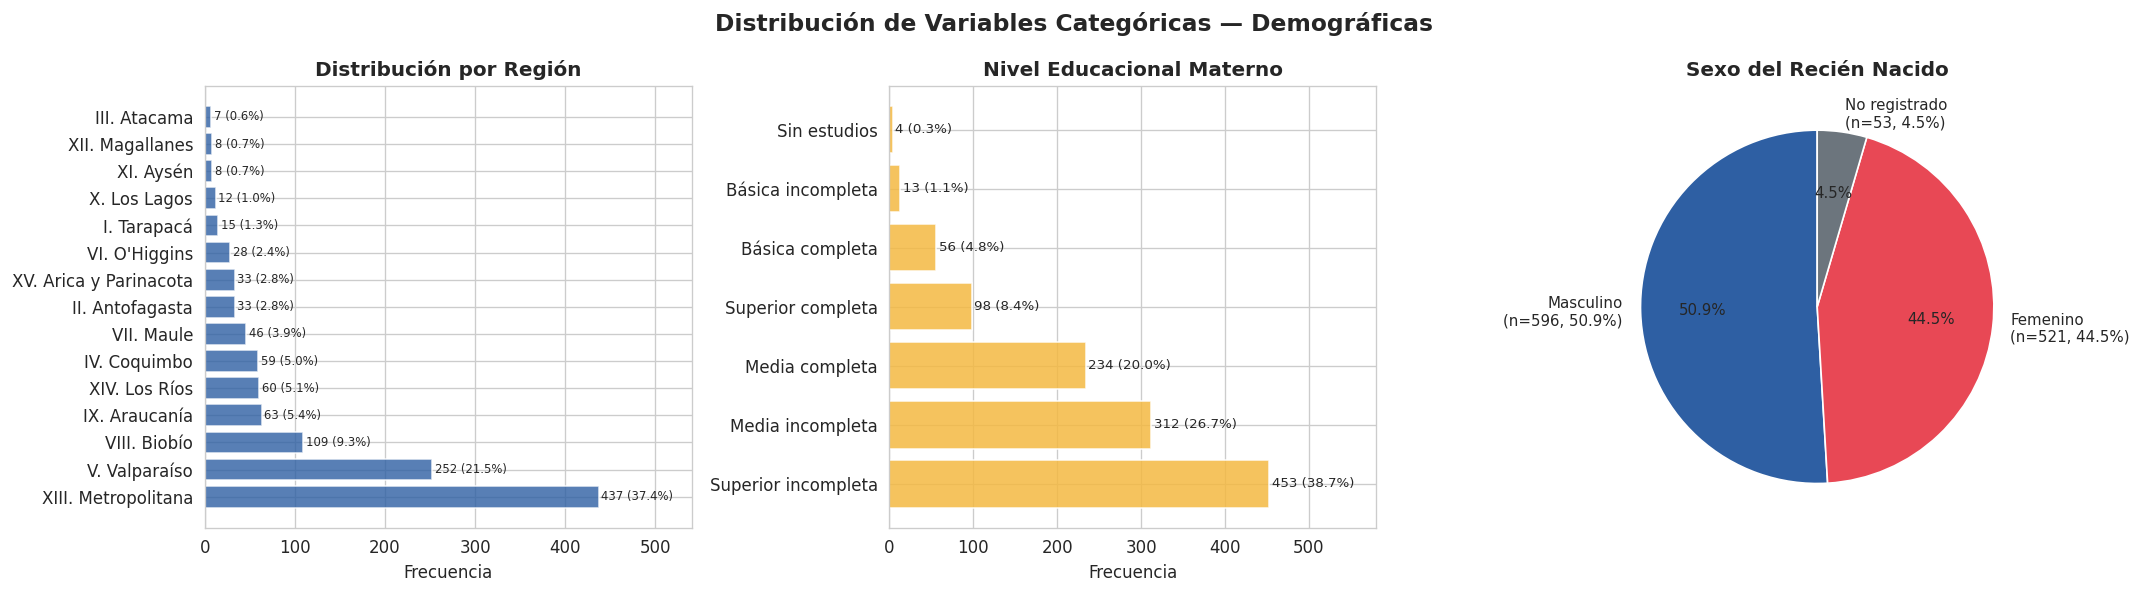

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribución de Variables Categóricas — Demográficas', fontsize=14, fontweight='bold')

# Región
ax = axes[0]
region_c = df['region_chile'].map(REGION_MAP).value_counts()
ax.barh(region_c.index, region_c.values, color=PALETTE['primary'], alpha=0.8)
for i, v in enumerate(region_c.values):
    ax.text(v + 3, i, f'{v} ({v/len(df)*100:.1f}%)', va='center', fontsize=7)
ax.set_title('Distribución por Región')
ax.set_xlabel('Frecuencia')
ax.set_xlim(0, 540)

# Nivel educacional
ax = axes[1]
neduc_c = df['neduc'].map(NEDUC_MAP).value_counts()
ax.barh(neduc_c.index, neduc_c.values, color=PALETTE['accent'], alpha=0.85)
for i, v in enumerate(neduc_c.values):
    ax.text(v + 3, i, f'{v} ({v/len(df)*100:.1f}%)', va='center', fontsize=8)
ax.set_title('Nivel Educacional Materno')
ax.set_xlabel('Frecuencia')
ax.set_xlim(0, 580)

# Sexo (pie)
ax = axes[2]
sexo_c = df['Sexo'].map(SEXO_MAP).value_counts()
ax.pie(sexo_c.values,
       labels=[f'{k}\n(n={v}, {v/len(df)*100:.1f}%)' for k, v in zip(sexo_c.index, sexo_c.values)],
       colors=[PALETTE['primary'], PALETTE['secondary'], PALETTE['gray']][:len(sexo_c)],
       autopct='%1.1f%%', startangle=90, pctdistance=0.65, textprops={'fontsize': 9})
ax.set_title('Sexo del Recién Nacido')

plt.tight_layout()
plt.show()

### Condición materna, tipo de pan y período de suplementación

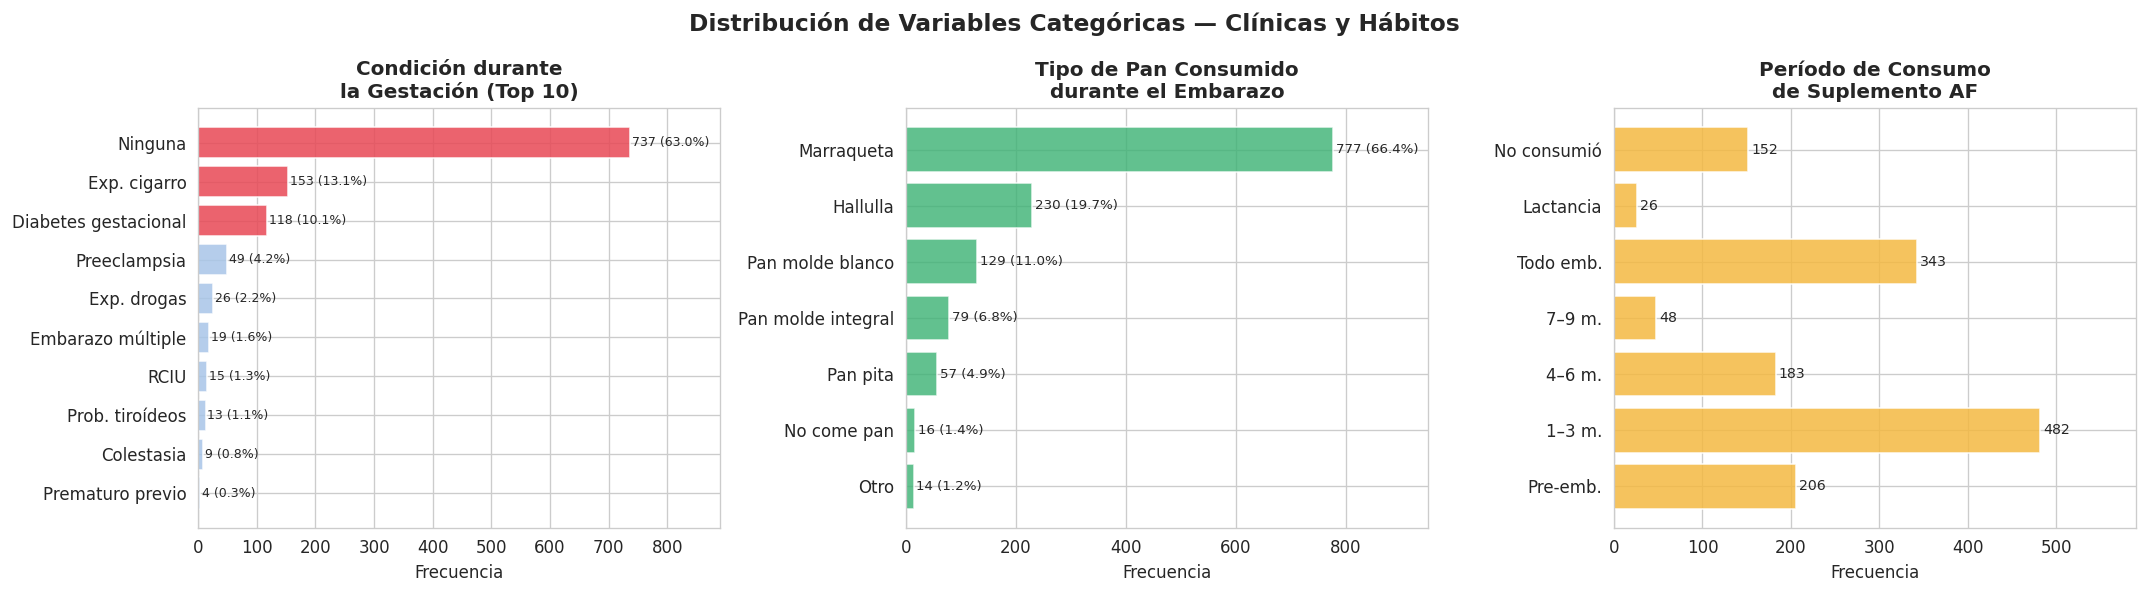

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribución de Variables Categóricas — Clínicas y Hábitos', fontsize=14, fontweight='bold')

# sitgest
ax = axes[0]
sitgest_c = df['sitgest'].map(SITGEST_MAP).value_counts().head(10)
colors_sg = [PALETTE['secondary'] if v > 50 else PALETTE['light'] for v in sitgest_c.values]
ax.barh(sitgest_c.index[::-1], sitgest_c.values[::-1], color=colors_sg[::-1], alpha=0.85)
for i, v in enumerate(sitgest_c.values[::-1]):
    ax.text(v + 3, i, f'{v} ({v/len(df)*100:.1f}%)', va='center', fontsize=7.5)
ax.set_title('Condición durante\nla Gestación (Top 10)')
ax.set_xlabel('Frecuencia')
ax.set_xlim(0, 890)

# Tipo de pan
ax = axes[1]
pan_s = df[pan_cols].sum().sort_values()
pan_labels_short = ['Otro','No come pan','Pan pita','Pan molde integral','Pan molde blanco','Hallulla','Marraqueta']
ax.barh(pan_labels_short, pan_s.values, color=PALETTE['green'], alpha=0.8)
for i, v in enumerate(pan_s.values):
    ax.text(v + 5, i, f'{v} ({v/len(df)*100:.1f}%)', va='center', fontsize=8)
ax.set_title('Tipo de Pan Consumido\ndurante el Embarazo')
ax.set_xlabel('Frecuencia')
ax.set_xlim(0, 950)

# Período de suplementación
ax = axes[2]
period_s = df[period_cols].sum()
period_l = ['Pre-emb.','1–3 m.','4–6 m.','7–9 m.','Todo emb.','Lactancia','No consumió']
ax.barh(period_l, period_s.values, color=PALETTE['accent'], alpha=0.85)
for i, v in enumerate(period_s.values):
    ax.text(v + 3, i, f'{v}', va='center', fontsize=8.5)
ax.set_title('Período de Consumo\nde Suplemento AF')
ax.set_xlabel('Frecuencia')
ax.set_xlim(0, 590)

plt.tight_layout()
plt.show()

<a id='8'></a>
## Mapa de calor de correlaciones

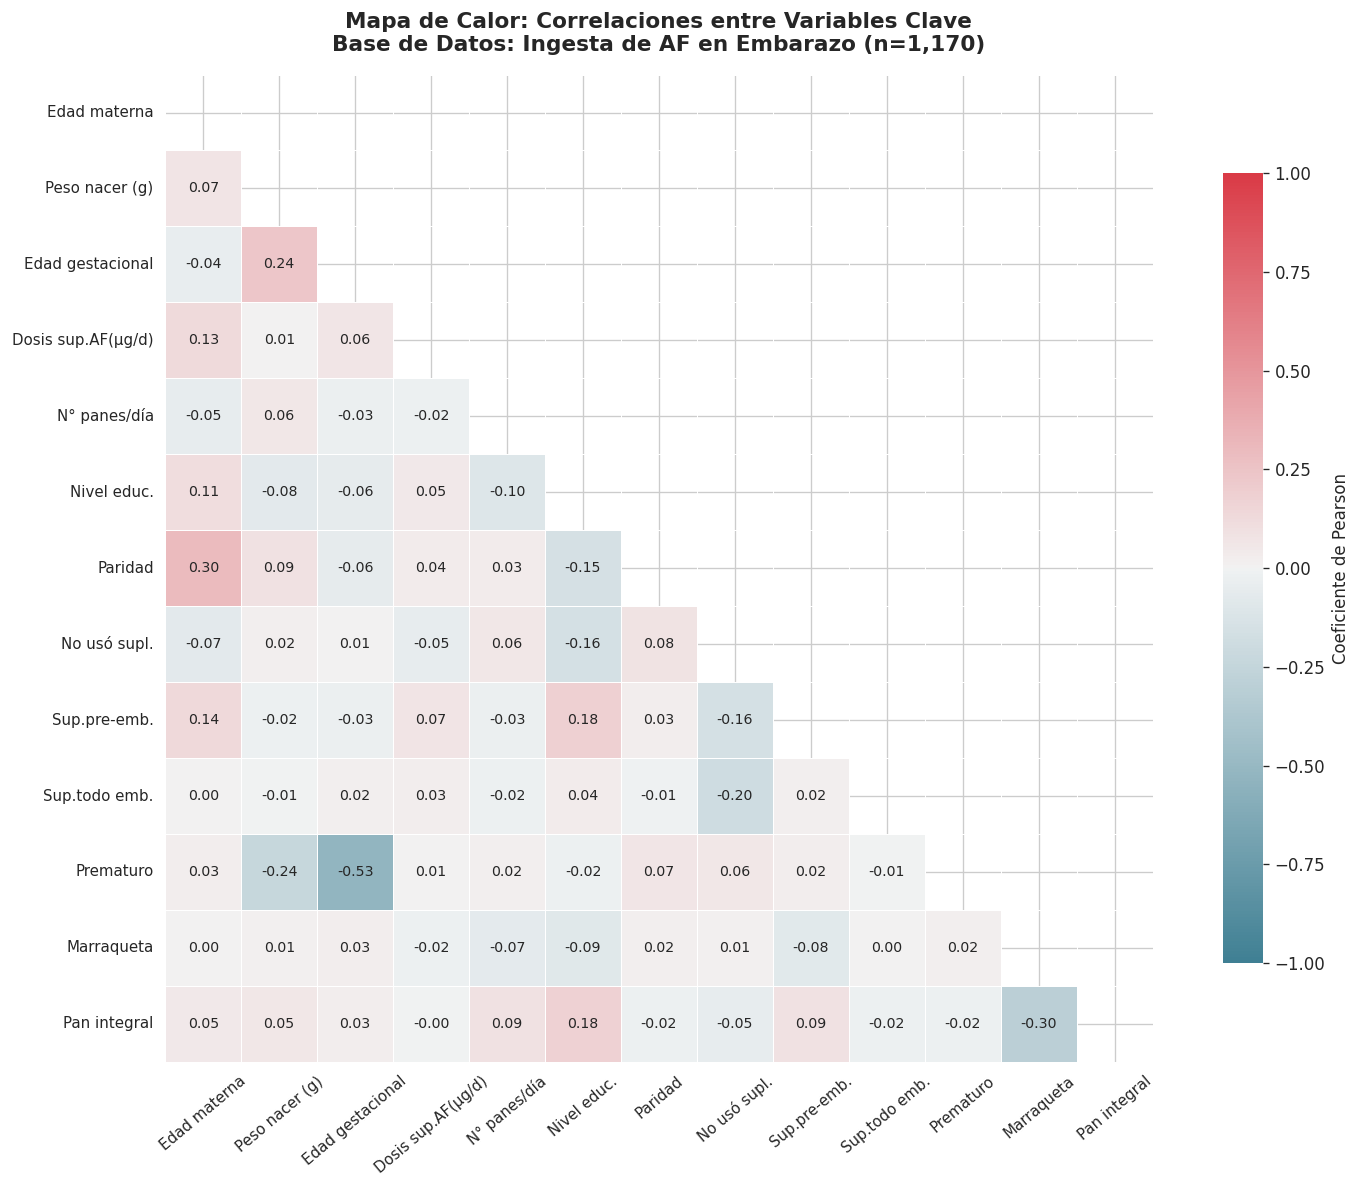


 Correlaciones más fuertes (|r| > 0.10) 


,Variable 1,Variable 2,r,|r|
47,Prematuro,Edad gestacional,-0.527900,0.527900
15,Paridad,Edad materna,0.299644,0.299644
77,Pan integral,Marraqueta,-0.298532,0.298532
46,Prematuro,Peso nacer (g),-0.240194,0.240194
2,Edad gestacional,Peso nacer (g),0.239060,0.239060
43,Sup.todo emb.,No usó supl.,-0.195176,0.195176
33,Sup.pre-emb.,Nivel educ.,0.182198,0.182198
71,Pan integral,Nivel educ.,0.176778,0.176778
35,Sup.pre-emb.,No usó supl.,-0.163136,0.163136
26,No usó supl.,Nivel educ.,-0.160809,0.160809


In [34]:
corr_df = pd.DataFrame({
    'Edad materna':        df['edad'],
    'Peso nacer (g)':      df['pnacer_raw'],
    'Edad gestacional':    df['eg_raw'],
    'Dosis sup.AF(µg/d)':  df['uf_af'],
    'N° panes/día':        df['n_panes'],
    'Nivel educ.':         df['neduc'],
    'Paridad':             pd.to_numeric(df['paridad'], errors='coerce'),
    'No usó supl.':        df['NO consumio'],
    'Sup.pre-emb.':        df['Antes del embarazo'],
    'Sup.todo emb.':       df['Durante todo el embarazo'],
    'Prematuro':           (df['eg_raw'] < 37).astype(float),
    'Marraqueta':          df['Marraqueta'],
    'Pan integral':        df['Pan molde integral'],
})

corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Pearson'},
            annot=True, fmt='.2f', annot_kws={'size': 8.5}, ax=ax)
ax.set_title('Mapa de Calor: Correlaciones entre Variables Clave\n'
             'Base de Datos: Ingesta de AF en Embarazo (n=1,170)',
             fontsize=13, fontweight='bold', pad=14)
ax.tick_params(axis='x', rotation=40, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.show()

# Correlaciones más fuertes
print('\n Correlaciones más fuertes (|r| > 0.10) ')
corr_stack = (corr_matrix.where(~mask)
              .stack()
              .reset_index()
              .rename(columns={'level_0':'Variable 1','level_1':'Variable 2',0:'r'}))
corr_stack['|r|'] = corr_stack['r'].abs()
corr_stack[corr_stack['|r|'] > 0.10].sort_values('|r|', ascending=False).head(15)

<a id='9'></a>
## Verificación de calidad de datos

###  Valores faltantes

Variables con valores faltantes
                                               Nulos  % faltante
uf-af                                            523       44.70
uf_af                                            523       44.70
fnacimiento                                      132       11.28
eg_raw                                           118       10.09
pnacer_raw                                       114        9.74
pnacer                                           111        9.49
Edad_gestacion ultimo hijo                       103        8.80
n_panes                                           34        2.91
Otro                                               2        0.17
edad                                               1        0.09
Diabetes gestacional                               1        0.09
Embarazo multiple                                  1        0.09
Restricción del crecimiento intrauterino RCIU      1        0.09
probnac                                            1      

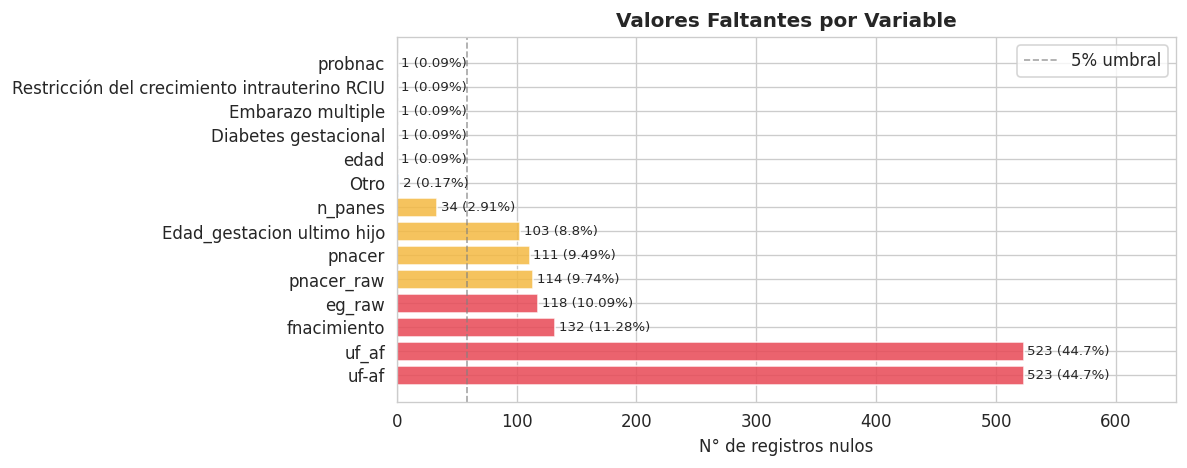

In [35]:
# Valores faltantes por columna (solo las que tienen nulos)
nulls = df.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
pct_nulls = (nulls / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Nulos': nulls, '% faltante': pct_nulls})
print('Variables con valores faltantes')
print(missing_df.to_string())

# Visualización
fig, ax = plt.subplots(figsize=(10, 4))
colors_miss = [PALETTE['secondary'] if p > 10 else PALETTE['accent'] if p > 2 else PALETTE['light']
               for p in pct_nulls.values]
ax.barh(nulls.index, nulls.values, color=colors_miss, alpha=0.85)
ax.axvline(len(df) * 0.05, color='gray', ls='--', lw=1, alpha=0.7, label='5% umbral')
for i, (v, p) in enumerate(zip(nulls.values, pct_nulls.values)):
    ax.text(v + 3, i, f'{v} ({p}%)', va='center', fontsize=8)
ax.set_title('Valores Faltantes por Variable', fontweight='bold')
ax.set_xlabel('N° de registros nulos')
ax.set_xlim(0, 650)
ax.legend()
plt.tight_layout()
plt.show()

### Detección de errores y valores erróneos

In [36]:
# Error 1: Edad materna imposible
print('Error 1: Edades maternas imposibles (> 60 años)')
print(df[df['edad'] > 60][['Cod', 'edad', 'fnacimiento']].to_string(index=False))

Error 1: Edades maternas imposibles (> 60 años)
 Cod  edad         fnacimiento
  79  85.0 2014-03-15 00:00:00
  84 227.0 2015-09-03 00:00:00


In [37]:
# Error 2: Entradas textuales en pnacer (embarazos gemelares)
print('Error 2: Pnacer con texto (embarazos gemelares)')
pnacer_texto = df['pnacer'][pd.to_numeric(df['pnacer'], errors='coerce').isna() & df['pnacer'].notna()]
print(pnacer_texto.reset_index(drop=False).to_string(index=False))

# Error 3: Pnacer extremo
print('\n Error 3: Peso al nacer extremadamente bajo (< 500 g)')
df_pnacer = df.copy()
df_pnacer['pnacer_num_tmp'] = pd.to_numeric(df_pnacer['pnacer'], errors='coerce')
print(df_pnacer[df_pnacer['pnacer_num_tmp'] < 500][['Cod','pnacer','eg_raw']].to_string(index=False))

Error 2: Pnacer con texto (embarazos gemelares)
 index      pnacer
    28 2225 y 2610
   466 2525 y 2460
  1165 2220 y 2190

 Error 3: Peso al nacer extremadamente bajo (< 500 g)
 Cod pnacer  eg_raw
 987    179    40.0


In [38]:
# Error 4: EG = 0 semanas
print('Error 4: Edad gestacional = 0 semanas')
print(df[df['eg_raw'] == 0][['Cod','eg_raw']].to_string(index=False))

# Error 5: EG con texto
print('\n Error 5: Edad gestacional con texto libre ("32 o menos") ')
eg_texto = df['Edad_gestacion ultimo hijo'][df['eg_raw'].isna() & df['Edad_gestacion ultimo hijo'].notna()]
print(eg_texto.value_counts())

Error 4: Edad gestacional = 0 semanas
 Cod  eg_raw
 586     0.0
1096     0.0

 Error 5: Edad gestacional con texto libre ("32 o menos") 
Edad_gestacion ultimo hijo
32 o menos    15
Name: count, dtype: int64


In [39]:
# Error 6: N° PANES con texto
print('Error 6: N° PANES con entradas no numéricas')
npanes_texto = df['N° PANES'][df['n_panes'].isna() & df['N° PANES'].notna()]
print(npanes_texto.value_counts())

Error 6: N° PANES con entradas no numéricas
N° PANES
5 o más unidades                                                  23
 No a diario                                                       1
Consumo ocasional de pan, no diario                                1
2 o 3 veces por semana                                             1
de vez en cuando comía alguno de los tipos recién mencionados.     1
Solo los fin de semana                                             1
Consumo esporadico, no diario                                      1
3 veces a la semana                                                1
2 por semana                                                       1
3 unidades a la semana                                             1
 3 unidades en la semana                                           1
2 a la semana                                                      1
Name: count, dtype: int64


In [40]:
# Error 7: sitgest y probnac con texto libre
print('Error 7: sitgest con texto libre')
sitgest_texto = df['sitgest'][pd.to_numeric(df['sitgest'], errors='coerce').isna() & df['sitgest'].notna()]
print(sitgest_texto.value_counts())

print('\n Error 8: probnac con texto libre ')
probnac_texto = df['probnac'][pd.to_numeric(df['probnac'], errors='coerce').isna() & df['probnac'].notna()]
print(probnac_texto.value_counts())

Error 7: sitgest con texto libre
sitgest
reposo adsoluto       1
reposo por 5 meses    1
Name: count, dtype: int64

 Error 8: probnac con texto libre 
probnac
no porque lo perdí fue anembrionico y formó fibroma    1
Sindrome de alaguille                                  1
Name: count, dtype: int64


In [41]:
# Duplicados
print(f'Registros duplicados (filas completas) : {df.duplicated().sum()}')
print(f'Códigos duplicados (Cod)               : {df["Cod"].duplicated().sum()} ')

Registros duplicados (filas completas) : 0
Códigos duplicados (Cod)               : 0 


<a id='10'></a>
## Corrección de errores y dataset limpio

In [42]:
df_clean = df.copy()

# 1: Edad materna imposible
mask_edad = df_clean['edad'] > 60
print(f'[C1] Edades imposibles eliminadas (→ NaN): {mask_edad.sum()} registros')
df_clean.loc[mask_edad, 'edad'] = np.nan

# 2: pnacer — gemelos y outlier extremo 
def parse_pnacer(v):
    if pd.isna(v): return np.nan
    try:
        return float(v)
    except:
        # Caso gemelos: "2225 y 2610" extraer primer valor
        primer = str(v).split('y')[0].strip()
        try:    return float(primer)
        except: return np.nan

df_clean['pnacer_num'] = df_clean['pnacer'].apply(parse_pnacer)
mask_pnacer_bajo = df_clean['pnacer_num'] < 500
print(f'[C2a] Pesos de gemelos parseados: 3 registros')
print(f'[C2b] Peso extremo < 500 g → NaN: {mask_pnacer_bajo.sum()} registros')
df_clean.loc[mask_pnacer_bajo, 'pnacer_num'] = np.nan

# 3: EG — texto '32 o menos' y EG = 0 
def parse_eg(v):
    if pd.isna(v): return np.nan
    try:
        f = float(v)
        return np.nan if f == 0 else f
    except:
        if '32 o menos' in str(v): return 32.0
        return np.nan

df_clean['eg_num'] = df_clean['Edad_gestacion ultimo hijo'].apply(parse_eg)
print(f'[C3a] "32 o menos" → 32.0: 15 registros')
print(f'[C3b] EG = 0 → NaN: 2 registros')

# 4: N° PANES — texto → numérico 
def parse_panes(v):
    if pd.isna(v): return np.nan
    try:
        return float(v)
    except:
        s = str(v).strip()
        if '5 o más' in s: return 5.0
        return np.nan  # No diario → NaN

df_clean['n_panes_num'] = df_clean['N° PANES'].apply(parse_panes)
print(f'[C4a] "5 o más unidades" → 5.0: 23 registros')
print(f'[C4b] Consumo no diario → NaN: ~11 registros')

# Variables Derivadas
# Indicador de parto prematuro
df_clean['prematuro'] = (df_clean['eg_num'] < 37).astype(float)
df_clean.loc[df_clean['eg_num'].isna(), 'prematuro'] = np.nan

# Categoría de edad gestacional
df_clean['eg_cat'] = pd.cut(
    df_clean['eg_num'],
    bins=[0, 32, 36, 38, 40, 42],
    labels=['≤32 (muy prematuro)', '33–36 (prematuro)', '37–38 (temprano)', '39–40 (normal)', '41–42 (postérmino)']
)

# Uso de suplemento
df_clean['uso_supl'] = np.where(df_clean['NO consumio'] == 1, 'No usó suplemento', 'Usó suplemento')

print(f'\n Dataset nuevo: {df_clean.shape[0]:,} registros × {df_clean.shape[1]} variables')
print(f'   Variables derivadas creadas: prematuro, eg_cat, uso_supl, pnacer_num, eg_num, n_panes_num')

[C1] Edades imposibles eliminadas (→ NaN): 2 registros
[C2a] Pesos de gemelos parseados: 3 registros
[C2b] Peso extremo < 500 g → NaN: 1 registros
[C3a] "32 o menos" → 32.0: 15 registros
[C3b] EG = 0 → NaN: 2 registros
[C4a] "5 o más unidades" → 5.0: 23 registros
[C4b] Consumo no diario → NaN: ~11 registros

 Dataset nuevo: 1,170 registros × 73 variables
   Variables derivadas creadas: prematuro, eg_cat, uso_supl, pnacer_num, eg_num, n_panes_num


In [43]:
resumen_nulos = pd.DataFrame({
    'Variable': ['edad', 'pnacer_num', 'eg_num', 'uf_af', 'n_panes_num'],
    'Nulos ANTES': [df['edad'].isna().sum(), 111, 103, df['uf_af'].isna().sum(), df['n_panes'].isna().sum()],
    'Nulos DESPUES': [df_clean['edad'].isna().sum(), df_clean['pnacer_num'].isna().sum(),
                      df_clean['eg_num'].isna().sum(), df_clean['uf_af'].isna().sum(),
                      df_clean['n_panes_num'].isna().sum()],
})
resumen_nulos['Diferencia'] = resumen_nulos['Nulos ANTES'] - resumen_nulos['Nulos DESPUES']
print('Impacto de la limpieza en valores nulos')
resumen_nulos

Impacto de la limpieza en valores nulos


,Variable,Nulos ANTES,Nulos DESPUES,Diferencia
0,edad,1,3,-2
1,pnacer_num,111,112,-1
2,eg_num,103,105,-2
3,uf_af,523,523,0
4,n_panes_num,34,11,23


<a id='11'></a>
## Análisis de relaciones clave

### Peso al nacer vs. Edad gestacional

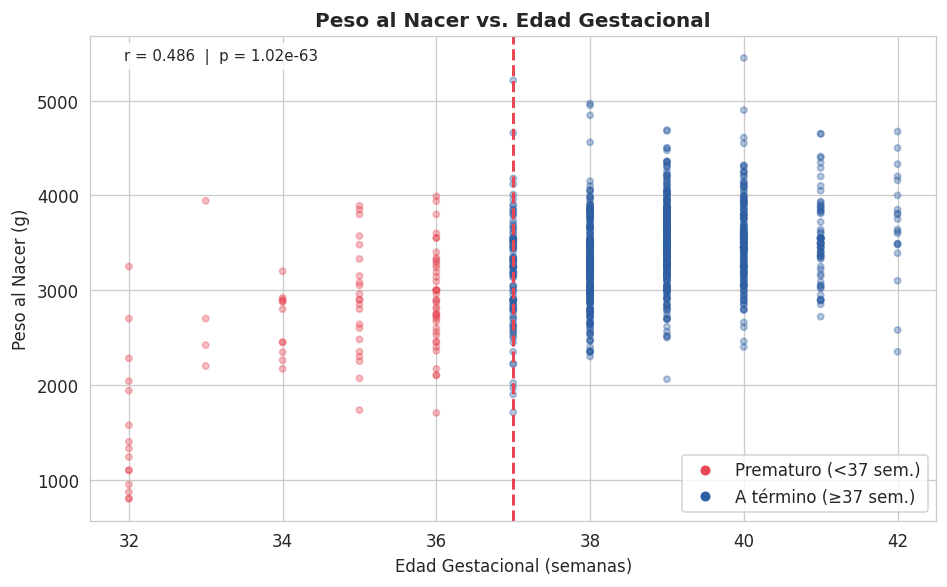

Partos prematuros (EG < 37 sem.): 94 / 1056 = 8.9%


In [44]:
data_s = df_clean[['pnacer_num', 'eg_num', 'prematuro']].dropna()

fig, ax = plt.subplots(figsize=(8, 5))
colors_s = [PALETTE['secondary'] if p == 1 else PALETTE['primary'] for p in data_s['prematuro']]
ax.scatter(data_s['eg_num'], data_s['pnacer_num'], c=colors_s, alpha=0.35, s=14)
ax.axvline(37, color=PALETTE['secondary'], ls='--', lw=1.8, label='37 sem. (umbral prematuro)')

r, p_val = stats.pearsonr(data_s['eg_num'], data_s['pnacer_num'])
ax.text(0.04, 0.95, f'r = {r:.3f}  |  p = {p_val:.2e}', transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

from matplotlib.lines import Line2D
handles = [Line2D([0],[0],marker='o',color='w',markerfacecolor=PALETTE['secondary'],markersize=7,label='Prematuro (<37 sem.)'),
           Line2D([0],[0],marker='o',color='w',markerfacecolor=PALETTE['primary'],markersize=7,label='A término (≥37 sem.)')]
ax.legend(handles=handles)
ax.set_xlabel('Edad Gestacional (semanas)')
ax.set_ylabel('Peso al Nacer (g)')
ax.set_title('Peso al Nacer vs. Edad Gestacional', fontweight='bold')
plt.tight_layout()
plt.show()

# Tasa de prematuridad
n_prem = int(data_s['prematuro'].sum())
n_total = len(data_s)
print(f'Partos prematuros (EG < 37 sem.): {n_prem} / {n_total} = {n_prem/n_total*100:.1f}%')

### Peso al nacer según uso de suplemento AF

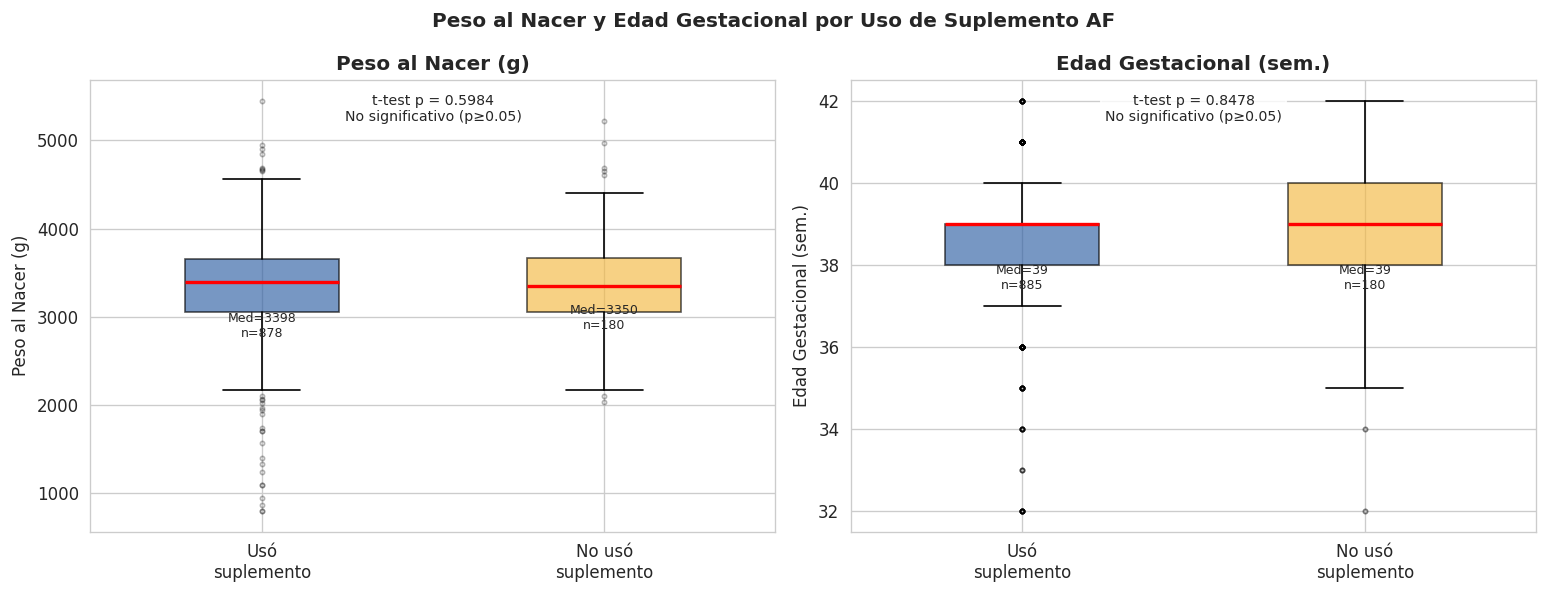

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Peso al Nacer y Edad Gestacional por Uso de Suplemento AF', fontweight='bold')

for ax, (resp_col, ylabel) in zip(axes, [('pnacer_num','Peso al Nacer (g)'), ('eg_num','Edad Gestacional (sem.)')]):
    grupos = [df_clean[df_clean['uso_supl'] == g][resp_col].dropna()
              for g in ['Usó suplemento', 'No usó suplemento']]
    bp = ax.boxplot(grupos, labels=['Usó\nsuplemento','No usó\nsuplemento'],
                    patch_artist=True, widths=0.45,
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markersize=2.5, alpha=0.3))
    bp['boxes'][0].set_facecolor(PALETTE['primary']);  bp['boxes'][0].set_alpha(0.65)
    bp['boxes'][1].set_facecolor(PALETTE['accent']);   bp['boxes'][1].set_alpha(0.65)
    t, p_t = stats.ttest_ind(grupos[0], grupos[1])
    sig = 'Significativo (p<0.05)' if p_t < 0.05 else 'No significativo (p≥0.05)'
    ax.text(0.5, 0.97, f't-test p = {p_t:.4f}\n{sig}', transform=ax.transAxes,
            ha='center', va='top', fontsize=8.5, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    for i, g in enumerate(grupos):
        ax.text(i+1, g.quantile(0.25) - (g.max()-g.min())*0.06,
                f'Med={g.median():.0f}\nn={len(g)}', ha='center', fontsize=7.5)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)

plt.tight_layout()
plt.show()

### Dosis de suplemento AF vs. resultados neonatales

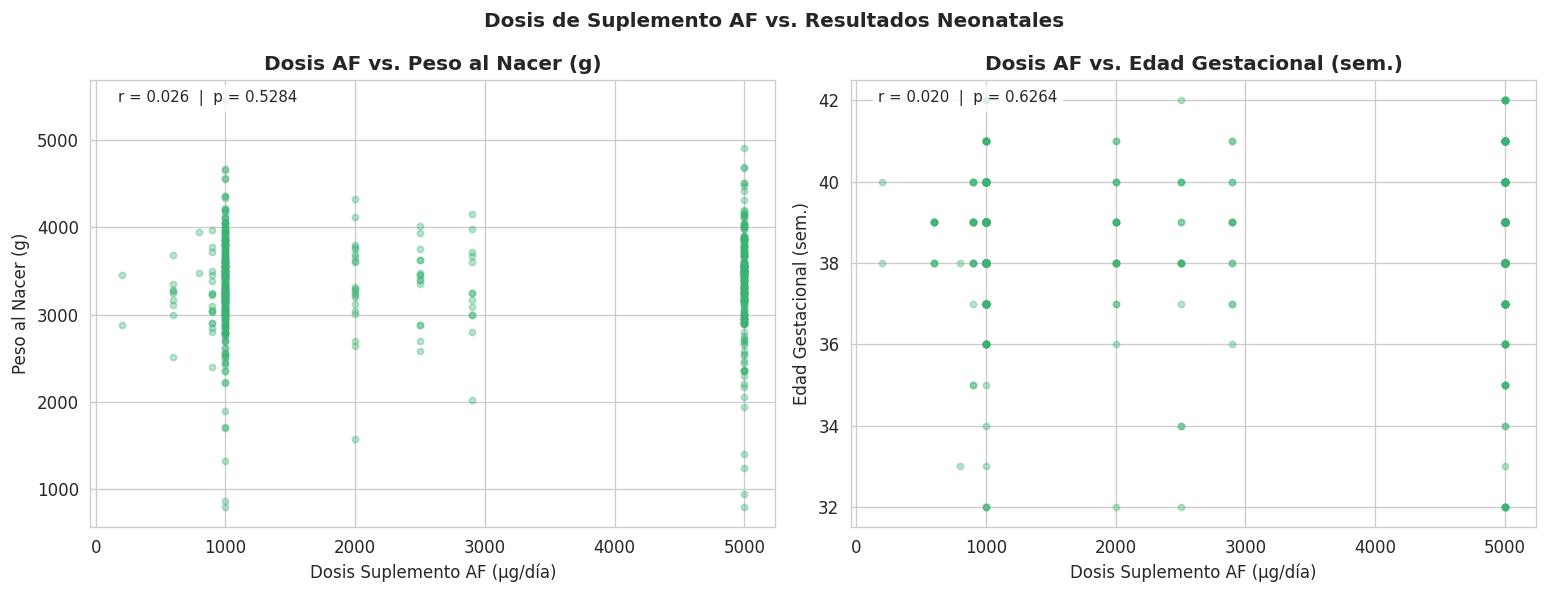

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Dosis de Suplemento AF vs. Resultados Neonatales', fontweight='bold')

for ax, (resp_col, ylabel) in zip(axes, [('pnacer_num','Peso al Nacer (g)'), ('eg_num','Edad Gestacional (sem.)')]):
    data_r = df_clean[['uf_af', resp_col]].dropna()
    ax.scatter(data_r['uf_af'], data_r[resp_col], alpha=0.35, s=14, color=PALETTE['green'])
    r, p_v = stats.pearsonr(data_r['uf_af'], data_r[resp_col])
    ax.text(0.04, 0.95, f'r = {r:.3f}  |  p = {p_v:.4f}', transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.set_xlabel('Dosis Suplemento AF (µg/día)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Dosis AF vs. {ylabel}')

plt.tight_layout()
plt.show()

In [51]:
from pathlib import Path

OUT_PATH = Path('..') / 'Data' / 'Ingesta_AF_clean_clean.csv'
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)

df_clean.to_csv(OUT_PATH, index=False)